# Model 3: Decision Tree: Coral Reef Regime Classification

Reproduces the **basic Decision Tree** model from *"Predicting Coral Reef Regimes from Human and Natural Influences"* (Walecka, Murphy, Cheng, CS 229).

**Task:** predict one of 4 reef regimes (1, 2, 3, 5) for 620 Hawaiian reef sites from 20 anthropogenic / biophysical predictors (+ 5 engineered features).

**Protocol (same as the paper):**
- Fixed 80/20 split → train+val = 496 rows, test = 124 rows (test used **once**, at the very end)
- 5-fold CV on the 496 training rows for validation scores and hyperparameter tuning
- Metric: micro-averaged F1 (we also report macro-F1 and per-class recall)

**What this notebook does**
1. Load data (auto-downloads from the authors' GitHub repo if not found locally)
2. Baseline: unconstrained tree (shows overfitting)
3. Tuned tree via grid search (`max_depth`, `min_samples_leaf`, `ccp_alpha`), with and without engineered features
4. Validation curves, feature importances, tree plot
5. Final one-shot evaluation on the test set + error analysis

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                             classification_report, recall_score)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 229          # same seed the authors use (CS 229)
CLASS_NAMES = ["Reg 1", "Reg 2", "Reg 3", "Reg 5"]

## 1. Load data
The repo ships the already-imputed ("complete") data, the 5 engineered features, and the fixed train / val / test split. The authors' original val split (100 rows) is merged back into train (396 + 100 = 496), because CV makes a separate val set unnecessary.

In [2]:
BASE = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Modeling/"
FILES = {"train": "Predictors_complete_train.txt",
         "val":   "Predictors_complete_val.txt",
         "test":  "Predictors_complete_test.txt"}

def read_split(name):
    local = os.path.join("..", "Data", "Modeling", FILES[name])   # works if run from repo/notebooks
    path = local if os.path.exists(local) else BASE + FILES[name]  # otherwise download (Colab etc.)
    df = pd.read_csv(path, sep="\t", decimal=",")
    return df.drop(df.columns[[0, 1]], axis=1)   # drop the two index columns saved by to_csv

train_raw, val_raw, test_raw = (read_split(s) for s in ["train", "val", "test"])
train = pd.concat([train_raw, val_raw], ignore_index=True)
test = test_raw.copy()
print("train+val:", train.shape, "| test:", test.shape)
print("Missing values in train:", int(train.isna().sum().sum()))

train+val: (496, 44) | test: (124, 44)
Missing values in train: 0


In [3]:
ORIG_FEATURES = ["Effluent","Sedimentation","New_Development","Habitat_Modification","Invasive_Algae",
                 "Fishing_Comm_Total","Fishing_NonComm_Boat_Total","Fishing_NonComm_Shore_Line",
                 "Fishing_NonComm_Shore_Net","Fishing_NonComm_Shore_Spear",
                 "SST_CLIM_M","SST_STD","CHL_CLIM_M","CHL_ANOM_F","PAR_CLIM_M","PAR_STD",
                 "WAV_CLIM_M","WAV_ANOM_F","Complexity","Depth"]               # 20 original predictors
ENG_FEATURES  = ["sqrt_power_x_compexity","log_power_over_depth","complexity_over_depth",
                 "Irradiance_x_inv_algae","both_anomolies"]                     # 5 engineered (name typo is the authors')
ALL_FEATURES = ORIG_FEATURES + ENG_FEATURES

def get_xy(df, feats):
    return df[feats].astype(float), df["Regime"].astype(int)

X_tr_orig, y_tr = get_xy(train, ORIG_FEATURES)
X_tr_all,  _    = get_xy(train, ALL_FEATURES)
X_te_orig, y_te = get_xy(test,  ORIG_FEATURES)
X_te_all,  _    = get_xy(test,  ALL_FEATURES)

print("Original features:", X_tr_orig.shape[1], "| With engineered:", X_tr_all.shape[1])
print("\nClass counts  (train):", y_tr.value_counts().sort_index().to_dict())
print("Class counts  (test): ", y_te.value_counts().sort_index().to_dict())

Original features: 20 | With engineered: 25

Class counts  (train): {1: 127, 2: 135, 3: 118, 5: 116}
Class counts  (test):  {1: 44, 2: 37, 3: 25, 5: 18}


## 2. Evaluation setup

For single-label multiclass classification, **micro-averaged F1 is mathematically identical to accuracy**. The paper's claim that micro-averaging "accounts for class imbalance" isn't accurate. We keep it as the headline metric to match the paper, but also track **macro-F1** and **per-class recall** (especially Regime 1, the "degraded" reef).

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = {"micro_f1": "f1_micro", "macro_f1": "f1_macro"}

def cv_report(model, X, y, label):
    res = cross_validate(model, X, y, cv=cv, scoring=SCORING, return_train_score=True)
    out = {"Model": label,
           "Train micro-F1": res["train_micro_f1"].mean(),
           "Val micro-F1":   res["test_micro_f1"].mean(),
           "Val std":        res["test_micro_f1"].std(),
           "Val macro-F1":   res["test_macro_f1"].mean()}
    return out

def plot_cm(y_true, y_pred, title):
    cm = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 5]),
                      index=CLASS_NAMES, columns=CLASS_NAMES)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="g", cmap="YlGnBu")
    plt.title(title); plt.ylabel("Actual label"); plt.xlabel("Predicted label")
    plt.tight_layout(); plt.show()

## 3. Baseline: unconstrained decision tree
With no depth limit, a tree can memorize the training set. This is the starting point we expect to overfit.

In [5]:
baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
results = [cv_report(baseline, X_tr_orig, y_tr, "Basic tree (orig. features, no limits)"),
           cv_report(baseline, X_tr_all,  y_tr, "Basic tree (+ engineered features, no limits)")]
pd.DataFrame(results).round(3)

,Model,Train micro-F1,Val micro-F1,Val std,Val macro-F1
0,"Basic tree (orig. features, no limits)",1.0,0.601,0.023,0.599
1,"Basic tree (+ engineered features, no limits)",1.0,0.570,0.063,0.565


## 4. Tune the tree with 5-fold CV
We search over `max_depth`, `min_samples_leaf` and cost-complexity pruning (`ccp_alpha`), selecting on **micro-F1**. This is run separately with and without the engineered features.

In [6]:
param_grid = {
    "max_depth":        [2, 3, 4, 5, 6, 7, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 15, 20],
    "ccp_alpha":        [0.0, 0.002, 0.005, 0.01, 0.02],
    "criterion":        ["gini", "entropy"],
}

def tune(X, y):
    gs = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), param_grid,
                      cv=cv, scoring="f1_micro", return_train_score=True, n_jobs=-1)
    return gs.fit(X, y)

gs_orig = tune(X_tr_orig, y_tr)
gs_all  = tune(X_tr_all,  y_tr)

for name, gs in [("Original features", gs_orig), ("+ Engineered features", gs_all)]:
    print(f"{name:24s} best CV micro-F1 = {gs.best_score_:.3f} | params = {gs.best_params_}")

Original features        best CV micro-F1 = 0.619 | params = {'ccp_alpha': 0.02, 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1}
+ Engineered features    best CV micro-F1 = 0.639 | params = {'ccp_alpha': 0.02, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5}


In [7]:
results += [cv_report(gs_orig.best_estimator_, X_tr_orig, y_tr, "Tuned tree (orig. features)"),
            cv_report(gs_all.best_estimator_,  X_tr_all,  y_tr, "Tuned tree (+ engineered features)")]
comparison = pd.DataFrame(results).round(3)
comparison

,Model,Train micro-F1,Val micro-F1,Val std,Val macro-F1
0,"Basic tree (orig. features, no limits)",1.000,0.601,0.023,0.599
1,"Basic tree (+ engineered features, no limits)",1.000,0.570,0.063,0.565
2,Tuned tree (orig. features),0.735,0.619,0.025,0.609
3,Tuned tree (+ engineered features),0.754,0.639,0.027,0.627


**Reading the table:** the gap between train and validation F1 shows how much each variant overfits. If the tuned and unconstrained trees land within about one standard deviation of each other on validation F1, the difference is noise. With 496 rows the CV standard deviation is a few points.

## 5. Validation curves
How validation F1 changes with tree depth (other hyperparameters at their defaults), a clean picture of the bias / variance trade-off.

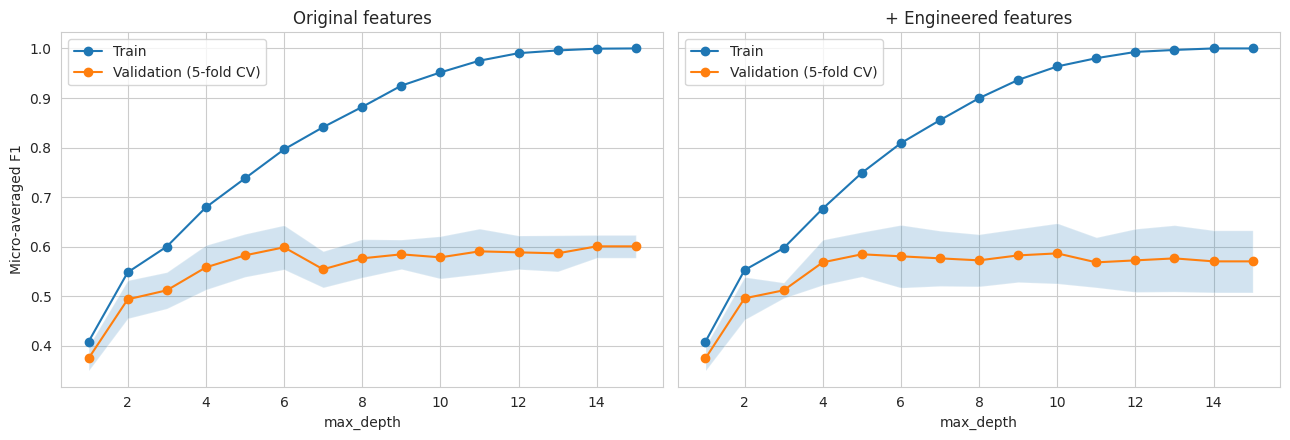

In [8]:
depths = list(range(1, 16))

def depth_curve(X, y):
    tr_s, va_s, va_sd = [], [], []
    for d in depths:
        r = cross_validate(DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE),
                           X, y, cv=cv, scoring="f1_micro", return_train_score=True)
        tr_s.append(r["train_score"].mean()); va_s.append(r["test_score"].mean()); va_sd.append(r["test_score"].std())
    return np.array(tr_s), np.array(va_s), np.array(va_sd)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (X, title) in zip(axes, [(X_tr_orig, "Original features"), (X_tr_all, "+ Engineered features")]):
    tr_s, va_s, va_sd = depth_curve(X, y_tr)
    ax.plot(depths, tr_s, "o-", label="Train")
    ax.plot(depths, va_s, "o-", label="Validation (5-fold CV)")
    ax.fill_between(depths, va_s - va_sd, va_s + va_sd, alpha=0.2)
    ax.set_title(title); ax.set_xlabel("max_depth"); ax.legend()
axes[0].set_ylabel("Micro-averaged F1")
plt.tight_layout(); plt.show()

## 6. Choose the final configuration
We pick whichever tuned variant has the higher CV micro-F1. The test set has still not been touched.

In [9]:
if gs_all.best_score_ >= gs_orig.best_score_:
    final_name, final_gs, X_tr_final, X_te_final, feats = "Tuned tree (+ engineered features)", gs_all, X_tr_all, X_te_all, ALL_FEATURES
else:
    final_name, final_gs, X_tr_final, X_te_final, feats = "Tuned tree (orig. features)", gs_orig, X_tr_orig, X_te_orig, ORIG_FEATURES

print("Selected:", final_name)
print("Params:  ", final_gs.best_params_)
print("CV micro-F1: %.3f" % final_gs.best_score_)

final_model = DecisionTreeClassifier(random_state=RANDOM_STATE, **final_gs.best_params_)
final_model.fit(X_tr_final, y_tr)          # refit on all 496 training rows
print("Tree depth: %d | leaves: %d" % (final_model.get_depth(), final_model.get_n_leaves()))

Selected: Tuned tree (+ engineered features)
Params:   {'ccp_alpha': 0.02, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5}
CV micro-F1: 0.639
Tree depth: 8 | leaves: 21


## 7. Feature importances and tree structure

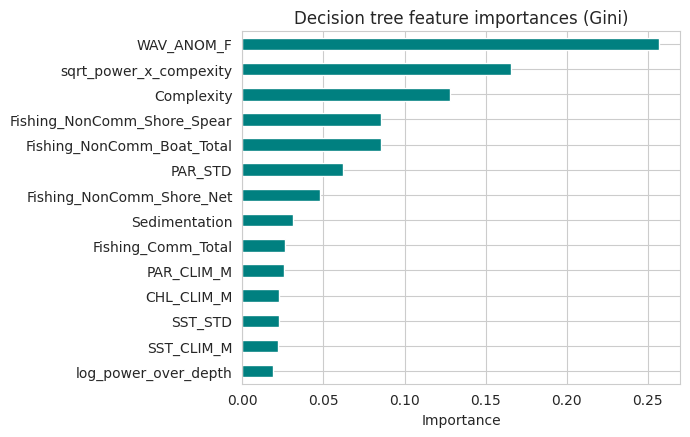

In [10]:
imp = pd.Series(final_model.feature_importances_, index=feats).sort_values(ascending=True)
imp = imp[imp > 0]
plt.figure(figsize=(7, max(3, 0.32 * len(imp))))
imp.plot.barh(color="teal")
plt.title("Decision tree feature importances (Gini)")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

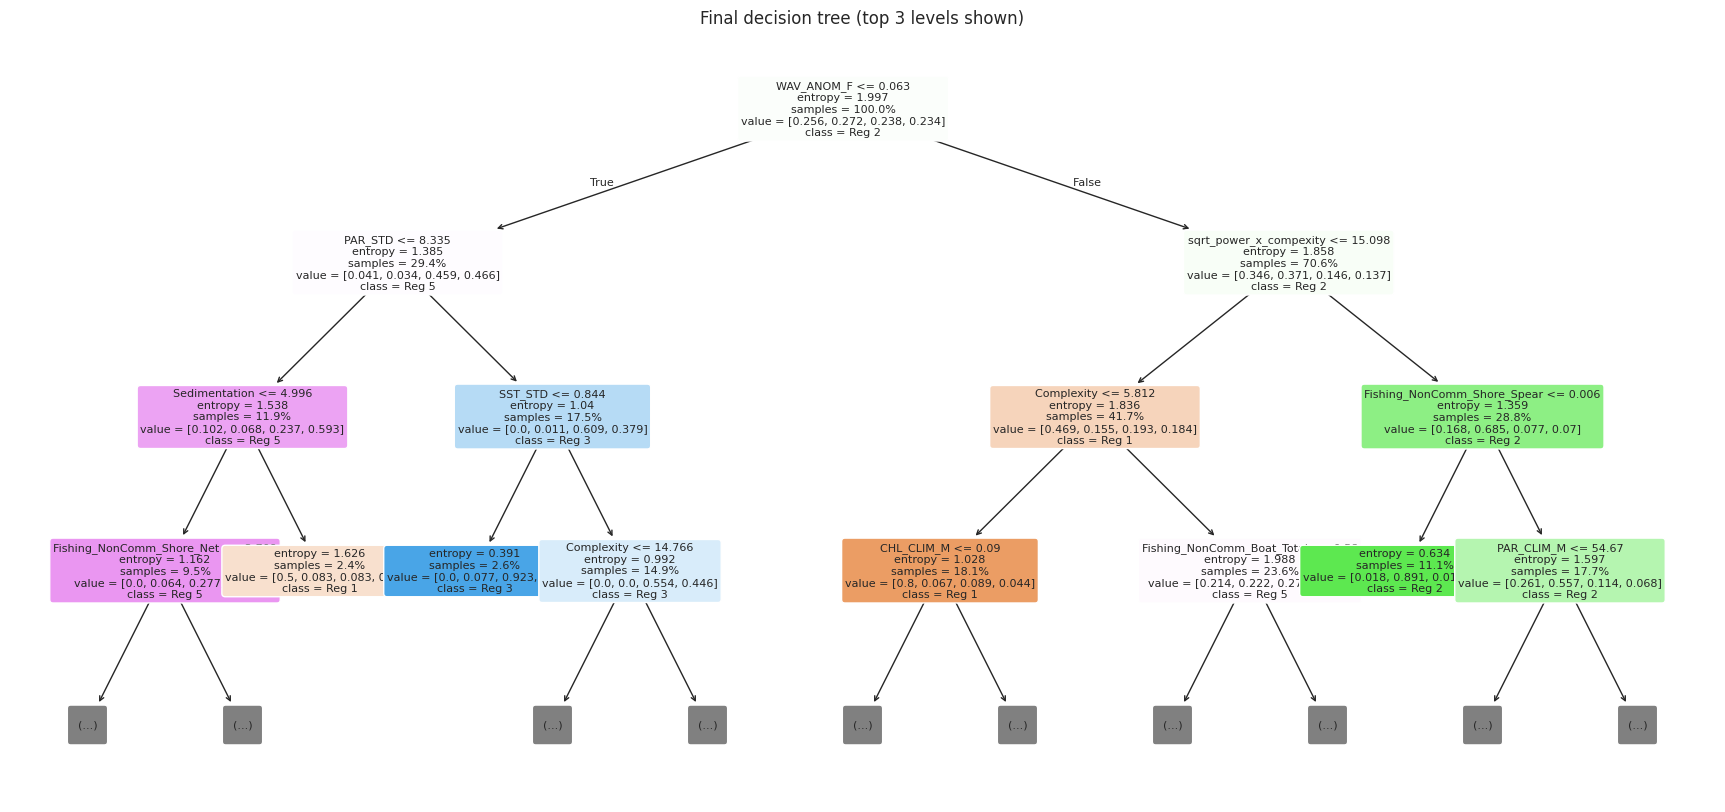

|--- WAV_ANOM_F <= 0.06
|   |--- PAR_STD <= 8.34
|   |   |--- Sedimentation <= 5.00
|   |   |   |--- Fishing_NonComm_Shore_Net <= 2.71
|   |   |   |   |--- class: 5
|   |   |   |--- Fishing_NonComm_Shore_Net >  2.71
|   |   |   |   |--- class: 3
|   |   |--- Sedimentation >  5.00
|   |   |   |--- class: 1
|   |--- PAR_STD >  8.34
|   |   |--- SST_STD <= 0.84
|   |   |   |--- class: 3
|   |   |--- SST_STD >  0.84
|   |   |   |--- Complexity <= 14.77
|   |   |   |   |--- class: 3
|   |   |   |--- Complexity >  14.77
|   |   |   |   |--- class: 5
|--- WAV_ANOM_F >  0.06
|   |--- sqrt_power_x_compexity <= 15.10
|   |   |--- Complexity <= 5.81
|   |   |   |--- CHL_CLIM_M <= 0.09
|   |   |   |   |--- class: 1
|   |   |   |--- CHL_CLIM_M >  0.09
|   |   |   |   |--- class: 1
|   |   |--- Complexity >  5.81
|   |   |   |--- Fishing_NonComm_Boat_Total <= 0.58
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Fishing_NonComm_Boat_Total >  0.58
|   |   |   |   |--- class: 1
|   |-

In [11]:
plt.figure(figsize=(22, 10))
plot_tree(final_model, feature_names=feats, class_names=CLASS_NAMES,
          filled=True, rounded=True, fontsize=8, max_depth=3, proportion=True)
plt.title("Final decision tree (top 3 levels shown)")
plt.show()

print(export_text(final_model, feature_names=feats, max_depth=3))

## 8. Final evaluation on the held-out test set (n = 124)
The test set is used **once**, with the model selected from CV alone.

Test micro-F1 : 0.645
Test macro-F1 : 0.629
Test accuracy : 0.645   (identical to micro-F1 for single-label multiclass)

Per-class report:
              precision    recall  f1-score   support

       Reg 1      0.702     0.750     0.725        44
       Reg 2      0.605     0.622     0.613        37
       Reg 3      0.619     0.520     0.565        25
       Reg 5      0.611     0.611     0.611        18

    accuracy                          0.645       124
   macro avg      0.634     0.626     0.629       124
weighted avg      0.643     0.645     0.643       124



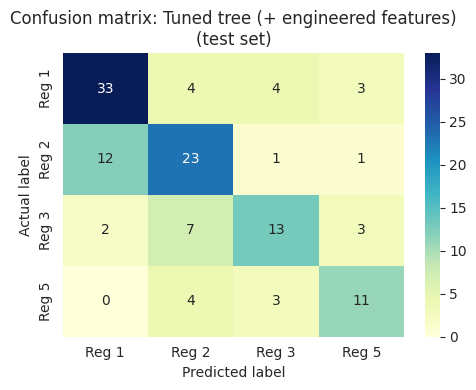

In [12]:
test_pred = final_model.predict(X_te_final)

print("Test micro-F1 : %.3f" % f1_score(y_te, test_pred, average="micro"))
print("Test macro-F1 : %.3f" % f1_score(y_te, test_pred, average="macro"))
print("Test accuracy : %.3f   (identical to micro-F1 for single-label multiclass)" % accuracy_score(y_te, test_pred))
print("\nPer-class report:")
print(classification_report(y_te, test_pred, target_names=CLASS_NAMES, digits=3))

plot_cm(y_te, test_pred, f"Confusion matrix: {final_name}\n(test set)")

## 9. Error analysis

In [13]:
cm = confusion_matrix(y_te, test_pred, labels=[1, 2, 3, 5])
recalls = recall_score(y_te, test_pred, average=None, labels=[1, 2, 3, 5])
print("Per-class recall:", dict(zip(CLASS_NAMES, recalls.round(3))))

# Most frequent off-diagonal confusions
errs = [(CLASS_NAMES[i], CLASS_NAMES[j], cm[i, j]) for i in range(4) for j in range(4) if i != j and cm[i, j] > 0]
errs.sort(key=lambda t: -t[2])
print("\nMost common confusions (actual -> predicted):")
for a, p, n in errs[:5]:
    print(f"  {a} -> {p}: {n}")

Per-class recall: {'Reg 1': np.float64(0.75), 'Reg 2': np.float64(0.622), 'Reg 3': np.float64(0.52), 'Reg 5': np.float64(0.611)}

Most common confusions (actual -> predicted):
  Reg 2 -> Reg 1: 12
  Reg 3 -> Reg 2: 7
  Reg 1 -> Reg 2: 4
  Reg 1 -> Reg 3: 4
  Reg 5 -> Reg 2: 4


## 10. Summary table (paper vs. this notebook)

The paper does not report a standalone basic decision tree, so there's no direct reference number. For context, its ensemble results were: **Random Forest 1.00 / 0.70** (train / val) and **Gradient Boosting 0.83 / 0.69**. A single tree is expected to be **below** both because it has high variance and no averaging.

In [14]:
summary = comparison.copy()
summary.loc[len(summary)] = ["FINAL: " + final_name + " (test set)", np.nan,
                             f1_score(y_te, test_pred, average="micro"), np.nan,
                             f1_score(y_te, test_pred, average="macro")]
summary.round(3)

,Model,Train micro-F1,Val micro-F1,Val std,Val macro-F1
0,"Basic tree (orig. features, no limits)",1.000,0.601,0.023,0.599
1,"Basic tree (+ engineered features, no limits)",1.000,0.570,0.063,0.565
2,Tuned tree (orig. features),0.735,0.619,0.025,0.609
3,Tuned tree (+ engineered features),0.754,0.639,0.027,0.627
4,FINAL: Tuned tree (+ engineered features) (tes...,NaN,0.645,NaN,0.629


### Notes
- **Imputation:** the paper says missing `Complexity` / `Depth` values were imputed with k-means. The authors' repo's `NA_estimation` notebook actually fills `Depth` with the median and `Complexity` with a lasso prediction, and this notebook uses that shipped data.
- **Why trees are noisy here:** with 496 rows, a single tree's CV score varies a lot between folds and seeds. Differences of 1-3 points between configurations are within noise.
- **Next:** Model 4 (Random Forest) and Model 5 (Gradient Boosting) can reuse the loading, CV and plotting cells above unchanged.